<a href="https://colab.research.google.com/github/mohak1206/fire-smoke-detection-yolov8/blob/main/fire_smoke_detection_yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.2 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="sTTCuKGaPL6SEFbsLD7x")
project = rf.workspace("space-3jvwp").project("fire-smoke-detection-lk8z9-vpblh")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 61.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fire--smoke-Detection-1 in yolov8:: 100%|██████████| 24249/24249 [00:03<00:00, 7710.25it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics import YOLO

# Load base model
model = YOLO('yolov8n.pt')

# Train
model.train(
    data=f'{dataset.location}/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='fire_smoke_v1',
    patience=10
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Fire--smoke-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fire_smoke_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d6b56843cb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
# See your mAP, precision, recall scores
metrics = model.val()

print("mAP@0.5:   ", metrics.box.map)
print("Precision: ", metrics.box.p)
print("Recall:    ", metrics.box.r)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1498.4±611.5 MB/s, size: 58.4 KB)
val: Scanning /content/Fire--smoke-Detection-1/valid/labels.cache... 1017 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1017/1017 355.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 4.3it/s 14.8s
                   all       1017       1118      0.677      0.639      0.663       0.33
                  fire        943       1021      0.873      0.896      0.912      0.484
                 smoke         94         97      0.481      0.381      0.415      0.177
Speed: 2.0ms preprocess, 4.4ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val
mAP@0.5:    0.3302024354948444
Precision:  [     0.8735     0.48123]
Recall:     [


image 1/1 /content/Fire--smoke-Detection-1/test/images/img_2126_aug1_jpg.rf.ded7f9b93455e621ca69d7955d784a54.jpg: 640x640 1 fire, 7.2ms
Speed: 2.0ms preprocess, 7.2ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


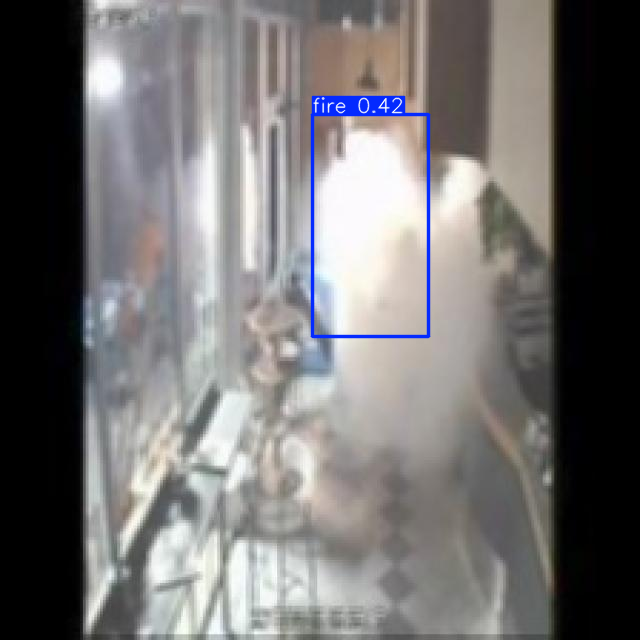

In [ ]:
import glob

# Pick one test image automatically
test_images = glob.glob(f'{dataset.location}/test/images/*.jpg')
test_img = test_images[0]

# Run detection
results = model.predict(source=test_img, save=True, conf=0.25)
results[0].show()

In [ ]:
from google.colab import files

# This downloads your best model weights to your computer
files.download('/content/runs/detect/fire_smoke_v1/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
version.deploy(model_type="yolov8",
               model_path=f"/content/runs/detect/fire_smoke_v1/")

Dependency ultralytics==8.0.196 is required but found version=8.4.46, to fix: `pip install ultralytics==8.0.196`
Would you like to continue with the wrong version of ultralytics? y/n: y
View the status of your deployment at: https://app.roboflow.com/space-3jvwp/fire-smoke-detection-lk8z9-vpblh/1
Share your model with the world at: https://universe.roboflow.com/space-3jvwp/fire-smoke-detection-lk8z9-vpblh/model/1


In [ ]:
!pip install ultralytics==8.0.196

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 631.1/631.1 kB 21.2 MB/s eta 0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.4.46
    Uninstalling ultralytics-8.4.46:
      Successfully uninstalled ultralytics-8.4.46


In [ ]:
# Check if model exists first
import os
exists = os.path.exists('/content/runs/detect/fire_smoke_v1/weights/best.pt')
print("Model exists:", exists)


Model exists: True


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="sTTCuKGaPL6SEFbsLD7x")
project = rf.workspace("space-3jvwp").project("fire-smoke-detection")
version = project.version(1)

version.deploy(
    model_type="yolov8",
    model_path="/content/runs/detect/fire_smoke_v1/"
)

loading Roboflow workspace...
loading Roboflow project...
Dependency ultralytics==8.0.196 is required but found version=8.4.46, to fix: `pip install ultralytics==8.0.196`
Would you like to continue with the wrong version of ultralytics? y/n: y
An error occured when getting the model upload URL: 404 Client Error: Not Found for url: https://api.roboflow.com/space-3jvwp/fire-smoke-detection/1/uploadModel?api_key=sTTCuKGaPL6SEFbsLD7x&modelType=yolov8&nocache=true


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="sTTCuKGaPL6SEFbsLD7x")
workspace = rf.workspace("space-3jvwp")

# This prints all your projects and their exact names
print(workspace.projects())


loading Roboflow workspace...
['space-3jvwp/fire-smoke-detection-iekbr', 'space-3jvwp/fire-smoke-detection-lk8z9-vpblh']


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="sTTCuKGaPL6SEFbsLD7x")

# Use exact workspace and project
workspace = rf.workspace("space-3jvwp")

# List projects to find exact name
for project in workspace.projects():
    print(project)

loading Roboflow workspace...
space-3jvwp/fire-smoke-detection-iekbr
space-3jvwp/fire-smoke-detection-lk8z9-vpblh


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="sTTCuKGaPL6SEFbsLD7x")
project = rf.workspace("space-3jvwp").project("fire-smoke-detection-1k8z9-vpblh")
version = project.version(1)

version.deploy(
    model_type="yolov8",
    model_path="/content/runs/detect/fire_smoke_v1/"
)

loading Roboflow workspace...
loading Roboflow project...


RoboflowError: {"error":{"message":"Unsupported request. `GET /space-3jvwp/fire-smoke-detection-1k8z9-vpblh` does not exist or cannot be loaded due to missing permissions.","type":"GraphMethodException","hint":"You can see your active workspace by issuing a GET request to `/` with your `api_key`."}}